# SDA: Stopwatch experiment

Everyone in class will use the stopwatch on their phone to measure time between the **Start** and **Stop** that will appear. We will repeat the experiment three times and the measured times will be combined in a shared spreadsheet.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii

## Read the data

The data of the stopwatch experiment can be found here: https://edu.nl/bqjv6

You can either just copy and paste the data from the sheet into this notebook:

In [2]:
data_str = \
"""
name	time_1	time_2	time_3
Tomas   1.0     1.0     1.0
"""

tdata = ascii.read(data_str)
print(tdata)

 name time_1 time_2 time_3
----- ------ ------ ------
Tomas    1.0    1.0    1.0


Or, download the data as CSV file from the Google sheet and read it from the CSV file:

In [3]:
tdata = ascii.read("stopwatch_data.csv", guess=False, format='csv')
print(tdata)

  name   time_1 time_2 time_3
-------- ------ ------ ------
   Thijn   6.44   7.42   7.42
   Noemi   7.36    7.3   7.55
    Dave   6.56   7.35   7.44
    Miko    7.1   7.31    6.8
     Tim   6.41   7.26   8.43
Johannes   7.73   5.34   7.22
  Wessel   6.95   7.46   7.45
   Chris   7.11    6.3   7.41
   Nando   6.52   7.33   7.46
     Eva    6.8   7.21   6.41
     ...    ...    ...    ...
    Luca    6.5    7.5    7.5
   Yentl    6.9    3.1    7.3
 Tristan    7.3   7.18    7.5
 Reinier   8.45   7.42   7.52
  Louisa    6.6    7.3    7.6
       -   6.21   7.13   7.46
 Chander   6.73   7.91   7.72
  Thirza    7.0    7.3    7.5
  Hannah   8.41   7.43   7.44
       -    7.1    7.6    7.5
Length = 36 rows


## Data analysis

In [4]:
plt.rcParams["figure.figsize"] = (5, 3)
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

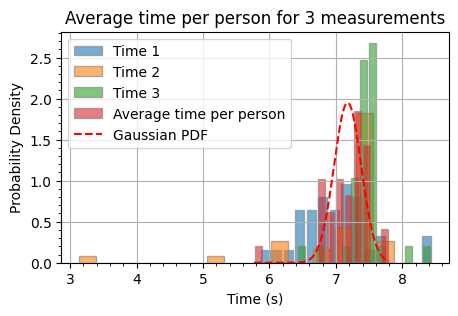

In [ ]:
from numpy import average


mu = np.mean([np.mean(tdata["time_1"]), np.mean(tdata["time_2"]), np.mean(tdata["time_3"])])
sigma = np.std([np.mean(tdata["time_1"]), np.mean(tdata["time_2"]), np.mean(tdata["time_3"])])
average_per_person = np.mean([tdata["time_1"], tdata["time_2"], tdata["time_3"]], axis=0)


plt.hist(tdata["time_1"], bins=15, density=True, alpha=0.6, edgecolor="gray", rwidth=0.8, label="Time 1")
plt.hist(tdata["time_2"], bins=15, density=True, alpha=0.6, edgecolor="gray", rwidth=0.8, label="Time 2")
plt.hist(tdata["time_3"], bins=15, density=True, alpha=0.6, edgecolor="gray", rwidth=0.8, label="Time 3")
plt.hist(average_per_person, bins=15, density=True, alpha=0.6, edgecolor="gray", rwidth=0.8, label="Average time per person")
plt.xlabel("Time (s)")
plt.ylabel("Probability Density")
plt.title("Average time per person for 3 measurements")
x = np.linspace(min(average_per_person), max(average_per_person), 1000)
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
plt.plot(x, pdf, color="red", label="Gaussian PDF", linestyle='--')
plt.legend()
plt.grid()
plt.show()


In [12]:
print(tdata['name'][27])

Yentl
